<a href="https://colab.research.google.com/github/derykian/2418005-Data-Cleansing/blob/main/2418005DataCleansing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Library

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

## 2. Upload Dataset

In [17]:
uploaded = files.upload()
file_name = next(iter(uploaded))

Saving 2418005_Employee-Management-Sample-Data.xlsx to 2418005_Employee-Management-Sample-Data (1).xlsx


## 3. Membaca Dataset

In [18]:
df = pd.read_excel(file_name, header=5)

# Menghapus kolom kosong yang tidak diperlukan
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

df.columns = df.columns.str.strip()

print("Jumlah baris dan kolom:", df.shape)
display(df.head())

Jumlah baris dan kolom: (40, 6)


,Employee ID,Full Name,Department,Designation,Hire Date,Annual Salary (USD)
0,S1001,John Smith,Human Resources,HR Manager,2023-05-15,60000
1,S1002,Jane Doe,Marketing,Marketing Specialist,2023-08-20,50000
2,S1003,Michael Johnson,Finance,Financial Analyst,2023-10-10,55000
3,S1004,Emily Brown,Sales,Sales Representative,2023-03-25,48000
4,S1005,David Wilson,Information Technology,IT Specialist,2023-09-12,60000


## 4. Memahami Struktur Dataset

In [19]:
df.info()

print("\nNama Kolom:")
print(df.columns.tolist())

print("\nStatistik Dataset:")
display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Employee ID          40 non-null     object        
 1   Full Name            40 non-null     object        
 2   Department           40 non-null     object        
 3   Designation          40 non-null     object        
 4   Hire Date            40 non-null     datetime64[ns]
 5   Annual Salary (USD)  40 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 2.0+ KB

Nama Kolom:
['Employee ID', 'Full Name', 'Department', 'Designation', 'Hire Date', 'Annual Salary (USD)']

Statistik Dataset:


,Employee ID,Full Name,Department,Designation,Hire Date,Annual Salary (USD)
count,40,40,40,40,40,40.000000
unique,40,37,10,40,NaN,NaN
top,S1001,Michael Johnson,Human Resources,HR Manager,NaN,NaN
freq,1,2,4,1,NaN,NaN
mean,NaN,NaN,NaN,NaN,2023-07-10 13:12:00,55150.000000
min,NaN,NaN,NaN,NaN,2023-01-17 00:00:00,40000.000000
25%,NaN,NaN,NaN,NaN,2023-04-25 12:00:00,48000.000000
50%,NaN,NaN,NaN,NaN,2023-07-11 00:00:00,53500.000000
75%,NaN,NaN,NaN,NaN,2023-09-22 12:00:00,62750.000000
max,NaN,NaN,NaN,NaN,2023-12-03 00:00:00,75000.000000


## 5. Identifikasi Missing Value dan Duplikasi

In [20]:
print("Missing Value:")
print(df.isnull().sum())

print("\nJumlah Duplikasi:")
print(df.duplicated().sum())

print("\nDuplikasi Employee ID:")
print(df['Employee ID'].duplicated().sum())

Missing Value:
Employee ID            0
Full Name              0
Department             0
Designation            0
Hire Date              0
Annual Salary (USD)    0
dtype: int64

Jumlah Duplikasi:
0

Duplikasi Employee ID:
0


## 6. Data Cleansing: Membersihkan Teks

In [21]:
text_columns = [
    'Employee ID',
    'Full Name',
    'Department',
    'Designation'
]

for col in text_columns:
    df[col] = df[col].astype('string').str.strip()

print("Pembersihan teks selesai.")
display(df.head())

Pembersihan teks selesai.


,Employee ID,Full Name,Department,Designation,Hire Date,Annual Salary (USD)
0,S1001,John Smith,Human Resources,HR Manager,2023-05-15,60000
1,S1002,Jane Doe,Marketing,Marketing Specialist,2023-08-20,50000
2,S1003,Michael Johnson,Finance,Financial Analyst,2023-10-10,55000
3,S1004,Emily Brown,Sales,Sales Representative,2023-03-25,48000
4,S1005,David Wilson,Information Technology,IT Specialist,2023-09-12,60000


## 7. Data Cleansing: Memperbaiki Tipe Data

In [22]:
df['Hire Date'] = pd.to_datetime(
    df['Hire Date'], errors='coerce'
)

df['Annual Salary (USD)'] = pd.to_numeric(
    df['Annual Salary (USD)'], errors='coerce'
)

print(df.dtypes)

Employee ID            string[python]
Full Name              string[python]
Department             string[python]
Designation            string[python]
Hire Date              datetime64[ns]
Annual Salary (USD)             int64
dtype: object


## 8. Data Cleansing: Menangani Missing Value

In [23]:
# Mengisi missing value gaji dengan median
median_salary = df['Annual Salary (USD)'].median()

df['Annual Salary (USD)'] = (
    df['Annual Salary (USD)'].fillna(median_salary)
)

# Missing value teks diisi Unknown
for col in ['Full Name', 'Department', 'Designation']:
    df[col] = df[col].fillna('Unknown')

print("Missing Value setelah penanganan:")
print(df.isnull().sum())

Missing Value setelah penanganan:
Employee ID            0
Full Name              0
Department             0
Designation            0
Hire Date              0
Annual Salary (USD)    0
dtype: int64


## 9. Data Cleansing: Menghapus Duplikasi

In [24]:
jumlah_awal = len(df)

df = df.drop_duplicates()

print("Data sebelum:", jumlah_awal)
print("Data sesudah:", len(df))
print("Duplikasi tersisa:", df.duplicated().sum())

Data sebelum: 40
Data sesudah: 40
Duplikasi tersisa: 0


## 10. Identifikasi Outlier Gaji

In [25]:
Q1 = df['Annual Salary (USD)'].quantile(0.25)
Q3 = df['Annual Salary (USD)'].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier = df[
    (df['Annual Salary (USD)'] < batas_bawah) |
    (df['Annual Salary (USD)'] > batas_atas)
]

print("Jumlah outlier:", len(outlier))
display(outlier)

Jumlah outlier: 0


,Employee ID,Full Name,Department,Designation,Hire Date,Annual Salary (USD)


## 11. Data Enrichment: Menambahkan Informasi Masa Kerja

In [26]:
tanggal_acuan = pd.Timestamp('2026-10-03')

df['Hire Year'] = df['Hire Date'].dt.year

df['Years of Service'] = (
    (tanggal_acuan - df['Hire Date']).dt.days / 365.25
).round(2)

print("Kolom enrichment berhasil ditambahkan.")
display(df.head())

Kolom enrichment berhasil ditambahkan.


,Employee ID,Full Name,Department,Designation,Hire Date,Annual Salary (USD),Hire Year,Years of Service
0,S1001,John Smith,Human Resources,HR Manager,2023-05-15,60000,2023,3.39
1,S1002,Jane Doe,Marketing,Marketing Specialist,2023-08-20,50000,2023,3.12
2,S1003,Michael Johnson,Finance,Financial Analyst,2023-10-10,55000,2023,2.98
3,S1004,Emily Brown,Sales,Sales Representative,2023-03-25,48000,2023,3.53
4,S1005,David Wilson,Information Technology,IT Specialist,2023-09-12,60000,2023,3.06


## 12. Data Enrichment: Menambahkan Kategori dan Gaji Bulanan

In [27]:
def kategori_masa_kerja(tahun):
    if pd.isna(tahun):
        return 'Tidak diketahui'
    elif tahun < 2:
        return 'Baru'
    elif tahun <= 5:
        return 'Menengah'
    else:
        return 'Senior'

df['Service Category'] = df['Years of Service'].apply(
    kategori_masa_kerja
)

df['Monthly Salary (USD)'] = (
    df['Annual Salary (USD)'] / 12
).round(2)

display(df.head())

,Employee ID,Full Name,Department,Designation,Hire Date,Annual Salary (USD),Hire Year,Years of Service,Service Category,Monthly Salary (USD)
0,S1001,John Smith,Human Resources,HR Manager,2023-05-15,60000,2023,3.39,Menengah,5000.00
1,S1002,Jane Doe,Marketing,Marketing Specialist,2023-08-20,50000,2023,3.12,Menengah,4166.67
2,S1003,Michael Johnson,Finance,Financial Analyst,2023-10-10,55000,2023,2.98,Menengah,4583.33
3,S1004,Emily Brown,Sales,Sales Representative,2023-03-25,48000,2023,3.53,Menengah,4000.00
4,S1005,David Wilson,Information Technology,IT Specialist,2023-09-12,60000,2023,3.06,Menengah,5000.00


## 13. Analisis dan Visualisasi Data

Jumlah Karyawan per Department:
Department
Human Resources             4
Marketing                   4
Finance                     4
Sales                       4
Information Technology      4
Operations                  4
Customer Service            4
Research and Development    4
Production                  4
Quality Assurance           4
Name: count, dtype: Int64


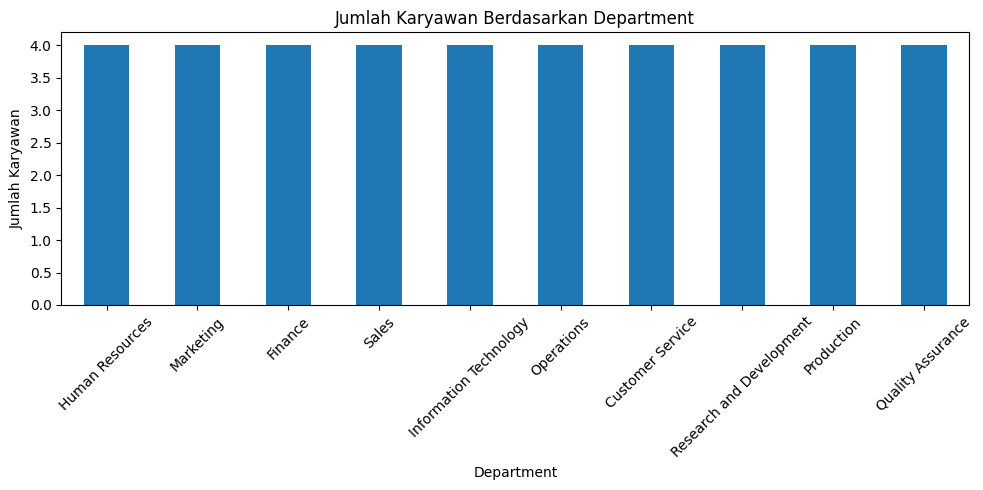


Rata-rata Gaji per Department:


,Annual Salary (USD)
Department,
Information Technology,63250.0
Quality Assurance,58750.0
Finance,58250.0
Sales,56250.0
Production,56000.0
Research and Development,54500.0
Operations,52500.0
Marketing,51250.0
Customer Service,50750.0


In [28]:
# Jumlah karyawan per departemen
department_count = df['Department'].value_counts()

print("Jumlah Karyawan per Department:")
print(department_count)

department_count.plot(kind='bar', figsize=(10, 5))
plt.title('Jumlah Karyawan Berdasarkan Department')
plt.xlabel('Department')
plt.ylabel('Jumlah Karyawan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Rata-rata gaji per departemen
print("\nRata-rata Gaji per Department:")
display(
    df.groupby('Department')['Annual Salary (USD)']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

## 14. Perbandingan dan Pemeriksaan Data Akhir

In [29]:
print("Jumlah Baris Akhir:", len(df))
print("Jumlah Kolom Akhir:", len(df.columns))

print("\nMissing Value:")
print(df.isnull().sum())

print("\nJumlah Duplikasi:")
print(df.duplicated().sum())

display(df.head(10))

Jumlah Baris Akhir: 40
Jumlah Kolom Akhir: 10

Missing Value:
Employee ID             0
Full Name               0
Department              0
Designation             0
Hire Date               0
Annual Salary (USD)     0
Hire Year               0
Years of Service        0
Service Category        0
Monthly Salary (USD)    0
dtype: int64

Jumlah Duplikasi:
0


,Employee ID,Full Name,Department,Designation,Hire Date,Annual Salary (USD),Hire Year,Years of Service,Service Category,Monthly Salary (USD)
0,S1001,John Smith,Human Resources,HR Manager,2023-05-15,60000,2023,3.39,Menengah,5000.00
1,S1002,Jane Doe,Marketing,Marketing Specialist,2023-08-20,50000,2023,3.12,Menengah,4166.67
2,S1003,Michael Johnson,Finance,Financial Analyst,2023-10-10,55000,2023,2.98,Menengah,4583.33
3,S1004,Emily Brown,Sales,Sales Representative,2023-03-25,48000,2023,3.53,Menengah,4000.00
4,S1005,David Wilson,Information Technology,IT Specialist,2023-09-12,60000,2023,3.06,Menengah,5000.00
5,S1006,Lisa Taylor,Operations,Operations Manager,2023-06-30,65000,2023,3.26,Menengah,5416.67
6,S1007,Daniel Martinez,Customer Service,Customer Service Representative,2023-11-05,45000,2023,2.91,Menengah,3750.00
7,S1008,Sarah Anderson,Research and Development,R&D Engineer,2023-04-18,58000,2023,3.46,Menengah,4833.33
8,S1009,Christopher Thomas,Production,Production Supervisor,2023-07-22,52000,2023,3.20,Menengah,4333.33
9,S1010,Kimberly Garcia,Quality Assurance,QA Analyst,2023-02-14,56000,2023,3.63,Menengah,4666.67


## 15. Menyimpan Dataset dan Kesimpulan

In [30]:
print("""
KESIMPULAN

1. Dataset Employee Management Data terdiri dari 40 data karyawan
   dengan 6 atribut utama.

2. Data cleansing dilakukan dengan membersihkan data teks,
   memeriksa dan memperbaiki tipe data, menghapus kolom yang
   tidak diperlukan, serta memeriksa missing value dan duplikasi.

3. Hasil pemeriksaan menunjukkan tidak terdapat duplikasi data,
   duplikasi Employee ID, maupun outlier pada Annual Salary.

4. Data enrichment dilakukan dengan menambahkan Hire Year,
   Years of Service, Service Category, dan Monthly Salary (USD).

5. Dataset akhir memiliki 40 baris dan 10 kolom serta siap
   digunakan untuk analisis data karyawan.
""")


KESIMPULAN

1. Dataset Employee Management Data terdiri dari 40 data karyawan
   dengan 6 atribut utama.

2. Data cleansing dilakukan dengan membersihkan data teks,
   memeriksa dan memperbaiki tipe data, menghapus kolom yang
   tidak diperlukan, serta memeriksa missing value dan duplikasi.

3. Hasil pemeriksaan menunjukkan tidak terdapat duplikasi data,
   duplikasi Employee ID, maupun outlier pada Annual Salary.

4. Data enrichment dilakukan dengan menambahkan Hire Year,
   Years of Service, Service Category, dan Monthly Salary (USD).

5. Dataset akhir memiliki 40 baris dan 10 kolom serta siap
   digunakan untuk analisis data karyawan.



In [31]:
print("=== PEMERIKSAAN AKHIR DATA ===")

print("Jumlah Baris :", len(df))
print("Jumlah Kolom :", len(df.columns))

print("\nMissing Value:")
print(df.isnull().sum())

print("\nJumlah Duplikasi:")
print(df.duplicated().sum())

print("\nDuplikasi Employee ID:")
print(df['Employee ID'].duplicated().sum())

print("\nNama Kolom:")
print(df.columns.tolist())

display(df.head(10))

=== PEMERIKSAAN AKHIR DATA ===
Jumlah Baris : 40
Jumlah Kolom : 10

Missing Value:
Employee ID             0
Full Name               0
Department              0
Designation             0
Hire Date               0
Annual Salary (USD)     0
Hire Year               0
Years of Service        0
Service Category        0
Monthly Salary (USD)    0
dtype: int64

Jumlah Duplikasi:
0

Duplikasi Employee ID:
0

Nama Kolom:
['Employee ID', 'Full Name', 'Department', 'Designation', 'Hire Date', 'Annual Salary (USD)', 'Hire Year', 'Years of Service', 'Service Category', 'Monthly Salary (USD)']


,Employee ID,Full Name,Department,Designation,Hire Date,Annual Salary (USD),Hire Year,Years of Service,Service Category,Monthly Salary (USD)
0,S1001,John Smith,Human Resources,HR Manager,2023-05-15,60000,2023,3.39,Menengah,5000.00
1,S1002,Jane Doe,Marketing,Marketing Specialist,2023-08-20,50000,2023,3.12,Menengah,4166.67
2,S1003,Michael Johnson,Finance,Financial Analyst,2023-10-10,55000,2023,2.98,Menengah,4583.33
3,S1004,Emily Brown,Sales,Sales Representative,2023-03-25,48000,2023,3.53,Menengah,4000.00
4,S1005,David Wilson,Information Technology,IT Specialist,2023-09-12,60000,2023,3.06,Menengah,5000.00
5,S1006,Lisa Taylor,Operations,Operations Manager,2023-06-30,65000,2023,3.26,Menengah,5416.67
6,S1007,Daniel Martinez,Customer Service,Customer Service Representative,2023-11-05,45000,2023,2.91,Menengah,3750.00
7,S1008,Sarah Anderson,Research and Development,R&D Engineer,2023-04-18,58000,2023,3.46,Menengah,4833.33
8,S1009,Christopher Thomas,Production,Production Supervisor,2023-07-22,52000,2023,3.20,Menengah,4333.33
9,S1010,Kimberly Garcia,Quality Assurance,QA Analyst,2023-02-14,56000,2023,3.63,Menengah,4666.67
